In [1]:
import numpy as np
import sempler
import sempler.generators
import src.utils as utils
import src.metrics as metrics

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import gridspec

import pickle
import os


import time

/home/juan/anaconda3/lib/python3.7/site-packages/rpy2/robjects/vectors.py:1008: UserWarning: R object inheriting from "POSIXct" but without attribute "tzone".
  warnings.warn('R object inheriting from "POSIXct" but without '
/home/juan/anaconda3/lib/python3.7/site-packages/pandas/core/arrays/datetimes.py:2192: PytzUsageWarning: The zone attribute is specific to pytz's interface; please migrate to a new time zone provider. For more details on how to do so, see https://pytz-deprecation-shim.readthedocs.io/en/latest/migration.html
  values, tz_parsed = conversion.datetime_to_datetime64(data.ravel("K"))


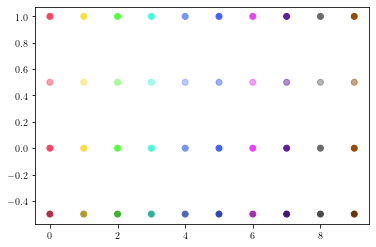

In [2]:
# Set tex formatting for plots
from matplotlib import rc
rc('font',**{'family':'serif','sans-serif':['Computer Modern Roman']})
rc('text', usetex=True)
#plt.rcParams["font.family"] = "serif"
#plt.rcParams["font.serif"] = ["Computer Modern Roman"]

# Set legend size
from matplotlib.font_manager import FontProperties
fontP = FontProperties()
fontP.set_size('medium')

# Colors
def to_rgb(H, b=1, a=1):
    RGBa = []
    for h in H:
        h = h.lstrip("#")
        RGBa.append(tuple(int(h[i:i+2], 16) / 256 * b for i in (0, 2, 4)) + (a,))
    return np.array(RGBa)

cmap = matplotlib.cm.get_cmap('tab20')
# Colorblind safe palettes
base = ['#d73027', '#f46d43', '#fdae61', '#fee090', '#020202', '#abd9e9', '#74add1', '#4575b4']
#base = ['#b2182b', '#d6604d', '#f4a582', '#fddbc7', '#d1e5f0', '#92c5de', '#4393c3', '#2166ac']
#base = ['#8c510a', '#bf812d', '#dfc27d', '#f6e8c3', '#c7eae5', '#80cdc1', '#35978f', '#01665e']
# Rainbow palette
base = ["#ff4365", "#ffdd43", "#59ff43", "#43ffdd", "#7395ff", "#4365ff", "#e943ff", "#601e9e", "#6a6a6a", "#964b00"]#np.array([cmap(i) for i in range(2,20)])
plt.scatter(np.arange(len(base)), np.ones(len(base)), c = base)
#base = [base[i] for i in [0,1,3]]
colors = to_rgb(base)
colorsa = to_rgb(base, a=0.5)
colorsb = to_rgb(base, b=0.7)
plt.scatter(np.arange(len(colors)), np.zeros(len(colors)), c = colors)
plt.scatter(np.arange(len(colors)), np.ones(len(colors))*0.5, c = colorsa)
plt.scatter(np.arange(len(colors)), np.ones(len(colors))*-0.5, c = colorsb)

## Load results

In [3]:
directory = "synthetic_experiments/dataset_1661334599_runs:10_seed:42_tag:I3s_G:100_k:2.7_p:10_w_min:0.5_w_max:1_v_min:1_v_max:2_envs:4_i_type:noise_i_size:1_i_v_min:5_i_v_max:10_n:10,100,1000_obs:1_standardize:1/"
directory_raw = "synthetic_experiments/dataset_1661334649_runs:10_seed:42_tag:I3_G:100_k:2.7_p:10_w_min:0.5_w_max:1_v_min:1_v_max:2_envs:4_i_type:noise_i_size:1_i_v_min:5_i_v_max:10_n:10,100,1000_obs:1_standardize:0/"

In [4]:
test_cases = utils.read_pickle(directory + 'test_cases.pickle')
test_casesr = utils.read_pickle(directory_raw + 'test_cases.pickle')
Ns = sorted(test_cases['Ns'])

**Varsortability**

In [5]:
Vs = test_cases['varsortability']
Vr = test_casesr['varsortability']

In [6]:
Vr.mean(), Vs.mean()

(0.9335630615758823, 0.5309141603091942)

**sortnregress**

In [7]:
sort_args, sort_results = utils.read_pickle(directory + "compiled_results_sortnregress_pool.pickle")
ground_truth, sort_metrics = utils.read_pickle(directory + "metrics_sortnregress_pool.pickle")
_, sort_metricsr = utils.read_pickle(directory_raw + "metrics_sortnregress_pool.pickle")

In [8]:
sort_metrics[metrics.success_metric].mean(axis=(0,2))

array([1., 1., 1.])

**sortnregress + pool**

In [9]:
sortp_args, sortp_results = utils.read_pickle(directory + "compiled_results_sortnregress_pool.pickle")
ground_truth, sortp_metrics = utils.read_pickle(directory + "metrics_sortnregress_pool.pickle")
_, sortp_metricsr = utils.read_pickle(directory_raw + "metrics_sortnregress_pool.pickle")

In [10]:
sortp_metrics[metrics.success_metric].mean(axis=(0,2))

array([1., 1., 1.])

**GnIES**

In [11]:
gnies_args, gnies_results = utils.read_pickle(directory + "compiled_results_gnies_fb.pickle")
ground_truth, gnies_metrics = utils.read_pickle(directory + "metrics_gnies_fb.pickle")
_, gnies_metricsr = utils.read_pickle(directory_raw + "metrics_gnies_fb.pickle")
gnies_lambdas = gnies_args[2]
gnies_lambdas

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]

In [12]:
gnies_metrics[metrics.success_metric].mean()

1.0

**GnIES + rank forward**

In [13]:
gnies_fr_args, gnies_fr_results = utils.read_pickle(directory + "compiled_results_gnies_f_rank.pickle")
ground_truth, gnies_fr_metrics = utils.read_pickle(directory + "metrics_gnies_f_rank.pickle")
_, gnies_fr_metricsr = utils.read_pickle(directory_raw + "metrics_gnies_f_rank.pickle")
gnies_fr_lambdas = gnies_args[2]
gnies_fr_lambdas

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]

In [14]:
gnies_fr_metrics[metrics.success_metric].mean()

1.0

**GnIES + rank backward**

In [15]:
gnies_br_args, gnies_br_results = utils.read_pickle(directory + "compiled_results_gnies_b_rank.pickle")
ground_truth, gnies_br_metrics = utils.read_pickle(directory + "metrics_gnies_b_rank.pickle")
_, gnies_br_metricsr = utils.read_pickle(directory_raw + "metrics_gnies_b_rank.pickle")
gnies_br_lambdas = gnies_args[2]
gnies_br_lambdas

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]

In [16]:
gnies_br_metrics[metrics.success_metric].mean()

1.0

**UT-IGSP**

In [17]:
ut_igsp_args, ut_igsp_results = utils.read_pickle(directory + "compiled_results_ut_igsp_gauss_obs:0.pickle")
ground_truth, utigsp_metrics = utils.read_pickle(directory + "metrics_ut_igsp_gauss_obs:0.pickle")
_, utigsp_metricsr = utils.read_pickle(directory_raw + "metrics_ut_igsp_gauss_obs:0.pickle")
utigsp_alphas, utigsp_betas = ut_igsp_args[1], ut_igsp_args[2]
utigsp_alphas, utigsp_betas

(array([1.00000e-05, 2.50075e-02, 5.00050e-02, 7.50025e-02, 1.00000e-01]),
 array([1.00000e-05, 2.50075e-02, 5.00050e-02, 7.50025e-02, 1.00000e-01]))

In [18]:
utigsp_metrics[metrics.success_metric].mean(axis=(0,1,2,4))

array([0.89868, 1.     , 1.     ])

**UT-IGSP+**

In [19]:
ut_igsp_plus_args, ut_igsp_plus_results = utils.read_pickle(directory + "compiled_results_ut_igsp_plus_gauss_obs:0.pickle")
ground_truth, utigsp_plus_metrics = utils.read_pickle(directory + "metrics_ut_igsp_plus_gauss_obs:0.pickle")
_, utigsp_plus_metricsr = utils.read_pickle(directory_raw + "metrics_ut_igsp_plus_gauss_obs:0.pickle")
utigsp_plus_alphas, utigsp_plus_betas = ut_igsp_args[1], ut_igsp_args[2]
utigsp_plus_alphas, utigsp_plus_betas

(array([1.00000e-05, 2.50075e-02, 5.00050e-02, 7.50025e-02, 1.00000e-01]),
 array([1.00000e-05, 2.50075e-02, 5.00050e-02, 7.50025e-02, 1.00000e-01]))

In [20]:
utigsp_plus_metrics[metrics.success_metric].mean()

0.9662266666666667

**GES**

In [21]:
ges_args, ges_results = utils.read_pickle(directory + "compiled_results_ges.pickle")
ground_truth, ges_metrics = utils.read_pickle(directory + "metrics_ges.pickle")
_, ges_metricsr = utils.read_pickle(directory_raw + "metrics_ges.pickle")
ges_lambdas = ges_args[2]
ges_lambdas

[0.01, 0.25, 0.5, 0.75, 1.0, 2.0]

In [22]:
ges_metrics[metrics.success_metric].mean()

1.0

## Figures

### Figure 1: Class recovery trajectories

In [23]:
gnies_x = np.nanmean(gnies_metrics[metrics.type_1_structc], axis=(0,3))
gnies_y = np.nanmean(gnies_metrics[metrics.type_2_structc], axis=(0,3))

gnies_fr_x = np.nanmean(gnies_fr_metrics[metrics.type_1_structc], axis=(0,3))
gnies_fr_y = np.nanmean(gnies_fr_metrics[metrics.type_2_structc], axis=(0,3))

gnies_br_x = np.nanmean(gnies_br_metrics[metrics.type_1_structc], axis=(0,3))
gnies_br_y = np.nanmean(gnies_br_metrics[metrics.type_2_structc], axis=(0,3))

idx = list(range(len(utigsp_alphas)))
utigsp_x = np.nanmean(utigsp_metrics[metrics.type_1_structc], axis=(0,4))[idx,idx]
utigsp_y = np.nanmean(utigsp_metrics[metrics.type_2_structc], axis=(0,4))[idx,idx]

idx = list(range(len(utigsp_plus_alphas)))
utigsp_plus_x = np.nanmean(utigsp_plus_metrics[metrics.type_1_structc], axis=(0,4))[idx,idx]
utigsp_plus_y = np.nanmean(utigsp_plus_metrics[metrics.type_2_structc], axis=(0,4))[idx,idx]

ges_x = np.nanmean(ges_metrics[metrics.type_1_structc], axis=(0,3))
ges_y = np.nanmean(ges_metrics[metrics.type_2_structc], axis=(0,3))

sort_x = np.nanmean(sort_metrics[metrics.type_1_structc], axis=(0,2))
sort_y = np.nanmean(sort_metrics[metrics.type_2_structc], axis=(0,2))

sortp_x = np.nanmean(sortp_metrics[metrics.type_1_structc], axis=(0,2))
sortp_y = np.nanmean(sortp_metrics[metrics.type_2_structc], axis=(0,2))

In [24]:
gnies_xr = np.nanmean(gnies_metricsr[metrics.type_1_structc], axis=(0,3))
gnies_yr = np.nanmean(gnies_metricsr[metrics.type_2_structc], axis=(0,3))

gnies_fr_xr = np.nanmean(gnies_fr_metricsr[metrics.type_1_structc], axis=(0,3))
gnies_fr_yr = np.nanmean(gnies_fr_metricsr[metrics.type_2_structc], axis=(0,3))

gnies_br_xr = np.nanmean(gnies_br_metricsr[metrics.type_1_structc], axis=(0,3))
gnies_br_yr = np.nanmean(gnies_br_metricsr[metrics.type_2_structc], axis=(0,3))

idx = list(range(len(utigsp_alphas)))
utigsp_xr = np.nanmean(utigsp_metricsr[metrics.type_1_structc], axis=(0,4))[idx,idx]
utigsp_yr = np.nanmean(utigsp_metricsr[metrics.type_2_structc], axis=(0,4))[idx,idx]

idx = list(range(len(utigsp_plus_alphas)))
utigsp_plus_xr = np.nanmean(utigsp_plus_metricsr[metrics.type_1_structc], axis=(0,4))[idx,idx]
utigsp_plus_yr = np.nanmean(utigsp_plus_metricsr[metrics.type_2_structc], axis=(0,4))[idx,idx]

ges_xr = np.nanmean(ges_metricsr[metrics.type_1_structc], axis=(0,3))
ges_yr = np.nanmean(ges_metricsr[metrics.type_2_structc], axis=(0,3))

sort_xr = np.nanmean(sort_metricsr[metrics.type_1_structc], axis=(0,2))
sort_yr = np.nanmean(sort_metricsr[metrics.type_2_structc], axis=(0,2))

sortp_xr = np.nanmean(sortp_metricsr[metrics.type_1_structc], axis=(0,2))
sortp_yr = np.nanmean(sortp_metricsr[metrics.type_2_structc], axis=(0,2))

In [25]:
sort_x

array([0.72428091, 0.73853356, 0.73694371])

In [26]:
sort_y

array([0.60194328, 0.55211221, 0.53520399])

gnies_rank_x = np.nanmean(gnies_rank_metrics[metrics.type_1_structc], axis=(0,3))
gnies_rank_y = np.nanmean(gnies_rank_metrics[metrics.type_2_structc], axis=(0,3))

### Combined: performance vs. computation time

In [27]:
def plot_elapsed_time(ax):
    black = "#2a2a2a"
    medianprops = {'color': '#2a2a2a', 'linestyle': "-"}
    meanprops = {'markerfacecolor': colors[0], 'marker': '.', 'markeredgecolor': colorsb[0]}
    boxprops = {'facecolor': 'white'}#colorsa[3]}#, 'hatch':"//////"}
    whiskerprops = {'color': black}    

    pos = np.array([0,2,4])
    # Plot scores for no pruning
    black = colorsb[0]
    bplot = ax.boxplot(gnies_metrics['times'][:,4,:,:].mean(axis=(2)),
                       showmeans=False,
                       positions=pos,
                       patch_artist=True,
                       medianprops = medianprops,
                       whiskerprops={'color': black},
                       boxprops = {'facecolor': colorsa[0], 'hatch': '...', 'edgecolor': black},
                       capprops = {'color': black},
                       flierprops={'markeredgecolor': black, 'markerfacecolor': colorsa[0]})

    j = 4
    delta = 0.7
    black = colorsb[j]
    bplot = ax.boxplot(gnies_fr_metrics['times'][:,4,:,:].mean(axis=(2)),
                       showmeans=False,
                       positions=pos + delta,
                       patch_artist=True,
                       medianprops = medianprops,
                       whiskerprops={'color': black},
                       boxprops = {'facecolor': colorsa[j],'edgecolor': black},
                       capprops = {'color': black},
                       flierprops={'markeredgecolor': colorsb[j], 'markerfacecolor': colorsa[j]})

    ax.set_xticks(pos + delta/2)
    ax.set_xticklabels([10,100,1000])
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylabel("Avg. test case runtime (seconds)")
    ax.set_xlabel("Obs. per environment")
    ax.set_title("Runtime for $\lambda=1$")

    # Build legend
    entries = [
            Patch(facecolor=colorsa[0], edgecolor=colorsb[0], hatch='...'),
            Patch(facecolor=colorsa[j], edgecolor=colorsb[j]),
        ]
    strings = ["GnIES - greedy", "GnIES - rank"]
    ax.legend(entries, strings)

    ax.legend(entries, strings, prop={'size': 8})

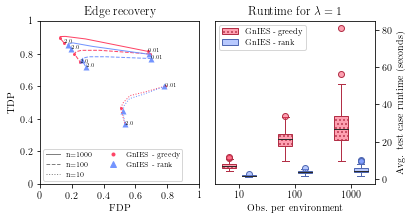

In [28]:
text = True
textsize = 5
lineopts = {'linewidth': 1}
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
marker = {'gnies': '.',
          'gnies_fr': '^',
          'gnies_br': '.',
          'ges': '*',
          'ut_igsp': '^',
          'ut_igsp+': '^',
          'sort': 's',
          'sortp': 'X',           
}
style = {'gnies': '-',
         'gnies_fr': '-',
         'gnies_br': ':',
         'ges': ':',
         'ut_igsp': ':',
         'ut_igsp+': '--',
         'sort': ':',
         'sortp': '--',
           
}
color = {'gnies': colors[0],
         'gnies_fr': colors[4],
         'gnies_br': colors[0],
         'ges': colors[1],
         'ut_igsp': colors[4],
         'ut_igsp+': colors[5],
         'sort': colors[2],
         'sortp': colors[2],
         
}

print_names = {'gnies': 'GnIES - greedy',
               'gnies_fr': 'GnIES - rank',
               'gnies_br': 'GnIES - rank forward',
               #'gnies_rank': 'GnIES-rank',
               'ges': 'GES',
               'ut_igsp': 'UT-IGSP',
               'ut_igsp+': 'UT-IGSP+',
               #'sort': 'sortnregress',         
               'sortp': 'sortnregress',
}

def plot_metric(ax, values_x, values_y, lambdas, method, points, text, gray=False):
    c = '#aaaaaa' if gray else color[method]
    values_y = 1 - values_y
    ax.plot(values_x, values_y, color=c, linestyle=style[method], **lineopts)
    for j, l in enumerate(lambdas):
        #ax.scatter(values_x[j], values_y[j], color=color[method], marker=".", linewidth=0)
        if j==0 and text[0] is not None:
            if l < 0.001:
                l = np.log10(l)
                fmt = "$10^{%d}$"
            else:
                fmt = "$"+text[0]+"$"
            ax.text(values_x[j], values_y[j], fmt % l, fontsize=textsize, ha="left")
        if l==lambdas[-1] and text[1] is not None:
            ax.text(values_x[j], values_y[j], ("$"+text[1]+"$") % l, fontsize=textsize, ha="left")
        if j in points:
            ax.scatter(values_x[j], values_y[j], color=c, marker=marker[method], linewidth=0)
            
def set_ax(ax, yticks=True):
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel('FDP')    
    ax.set_ylabel('TDP') if yticks else None
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks) if yticks else ax.set_yticklabels([])


gs = gridspec.GridSpec(1, 2, wspace=0.10, hspace=0.2)
plt.figure(figsize=(6,3))
ax = plt.gca()

for i,n in enumerate(Ns):
    plt.subplot(gs[0])
    ax = plt.gca()
    if i==0:
        ax0 = ax
    
    if n== 10:
        style['gnies'] = ':'
        style['gnies_fr'] = ':'
    if n== 100:
        style['gnies'] = '--'
        style['gnies_fr'] = '--'
    if n== 1000:
        style['gnies'] = '-'
        style['gnies_fr'] = '-'
         
    
    # Plot GnIES
    plot_metric(ax, gnies_x[:,i], gnies_y[:,i], gnies_lambdas, 'gnies', [0,4,len(gnies_lambdas)-1], ["%0.2f" if n!=100 else None,"%0.1f" if n!=10 else None])
    
    # Plot GnIES - rank forward
    plot_metric(ax, gnies_fr_x[:,i], gnies_fr_y[:,i], gnies_fr_lambdas, 'gnies_fr', [0,4,len(gnies_fr_lambdas)-1], ["%0.2f" if n==100 else None, "%0.1f"])
        
    set_ax(ax, yticks=True)
    ax.set_title("Edge recovery")


# Build legend
method_entries = [Line2D([0], [0], linewidth=1, linestyle=s, color='gray') for s in ['-', '--', ':']]
method_entries += [Line2D([0], [0],
                         linewidth=0,
                         linestyle=style[method],
                         marker=marker[method],
                         color=color[method]) for method in ['gnies', 'gnies_fr']]


method_str = ["n=%d" % n for n in [1000,100,10]]
method_str += [print_names[method] for method in ['gnies', 'gnies_fr']]

ax.legend(method_entries, #+ sample_size_entries
          method_str, # + sample_size_str
          prop={'size':7},
          loc='lower left',
          ncol=2)


plt.subplot(gs[1])
ax = plt.gca()
plot_elapsed_time(ax)

plt.savefig('figures/figure_greedy_vs_rank_single.pdf', bbox_inches='tight')

### Elapsed time with all other algorithms

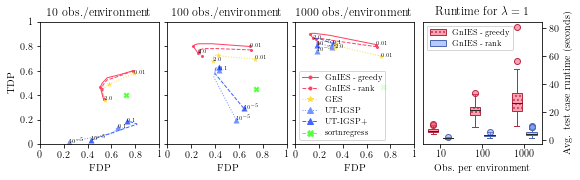

In [37]:
text = True
textsize = 5
lineopts = {'linewidth': 1}
ticks = [0, 0.2, 0.4, 0.6, 0.8, 1]
marker = {'gnies': '.',
          'gnies_fr': '.',
          'gnies_br': '.',
          'ges': '*',
          'ut_igsp': '^',
          'ut_igsp+': '^',
          'sort': 's',
          'sortp': 'X',           
}
style = {'gnies': '-',
         'gnies_fr': '--',
         'gnies_br': ':',
         'ges': ':',
         'ut_igsp': ':',
         'ut_igsp+': '--',
         'sort': ':',
         'sortp': '--',
           
}
color = {'gnies': colors[0],
         'gnies_fr': colors[0],
         'gnies_br': colors[0],
         'ges': colors[1],
         'ut_igsp': colors[4],
         'ut_igsp+': colors[5],
         'sort': colors[2],
         'sortp': colors[2],
         
}

print_names = {'gnies': 'GnIES - greedy',
               'gnies_fr': 'GnIES - rank',
               #'gnies_br': 'GnIES - rank backward',
               #'gnies_rank': 'GnIES-rank',
               'ges': 'GES',
               'ut_igsp': 'UT-IGSP',
               'ut_igsp+': 'UT-IGSP+',
               #'sort': 'sortnregress',         
               'sortp': 'sortnregress',
}

def plot_metric(ax, values_x, values_y, lambdas, method, points, text, gray=False):
    c = '#aaaaaa' if gray else color[method]
    values_y = 1 - values_y
    ax.plot(values_x, values_y, color=c, linestyle=style[method], **lineopts)
    for j, l in enumerate(lambdas):
        #ax.scatter(values_x[j], values_y[j], color=color[method], marker=".", linewidth=0)
        if j==0 and text[0] is not None:
            if l < 0.001:
                l = np.log10(l)
                fmt = "$10^{%d}$"
            else:
                fmt = "$"+text[0]+"$"
            ax.text(values_x[j], values_y[j], fmt % l, fontsize=textsize, ha="left")
        if l==lambdas[-1] and text[1] is not None:
            ax.text(values_x[j], values_y[j], ("$"+text[1]+"$") % l, fontsize=textsize, ha="left")
        if j in points:
            ax.scatter(values_x[j], values_y[j], color=c, marker=marker[method], linewidth=0)
            
def set_ax(ax, yticks=True):
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.set_xlabel('FDP')    
    ax.set_ylabel('TDP') if yticks else None
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(ticks) if yticks else ax.set_yticklabels([])


gs = gridspec.GridSpec(1, 4, wspace=0.07, hspace=0.35)
plt.figure(figsize=(9,2.25))
ax = plt.gca()

for i,n in enumerate(Ns):
    plt.subplot(gs[i])
    ax = plt.gca()
    if i==0:
        ax0 = ax
    
    # Plot GnIES
    plot_metric(ax, gnies_x[:,i], gnies_y[:,i], gnies_lambdas, 'gnies', [0,4,len(gnies_lambdas)-1], [None if n==10 else "%0.2f","%0.1f"])
    
    # Plot GnIES - rank forward
    plot_metric(ax, gnies_fr_x[:,i], gnies_fr_y[:,i], gnies_fr_lambdas, 'gnies_fr', [0,4,len(gnies_fr_lambdas)-1], [None, None])
    
    # Plot GnIES - rank backward
    #plot_metric(ax, gnies_br_x[:,i], gnies_br_y[:,i], gnies_br_lambdas, 'gnies_br', [0,2,len(gnies_br_lambdas)-1], [None if n==10 else "%0.2f","%0.1f"])
    
    # Plot UT-IGSP
    plot_metric(ax, utigsp_x[:,i], utigsp_y[:,i], utigsp_alphas, 'ut_igsp', [0,len(utigsp_alphas)-1], ["%0.1f",None if n==1000 else "%0.1f"])

    # Plot UT-IGSP+
    plot_metric(ax, utigsp_plus_x[:,i], utigsp_plus_y[:,i], utigsp_plus_alphas, 'ut_igsp+', [0,len(utigsp_plus_alphas)-1], ["%0.1f","%0.1f" if n!=100 else None])

    # Plot GES
    plot_metric(ax, ges_x[:,i], ges_y[:,i], ges_lambdas, 'ges', [0,2,len(ges_lambdas)-1], ["%0.2f",None if n==10 else "%0.1f"])
    
    # Plot sortnregress + pool
    ax.scatter(sortp_x[i], 1-sortp_y[i], color=color['sortp'], marker=marker['sortp'], linewidth=0)
    
    set_ax(ax, yticks=i in [0])
    ax.set_title("%d obs./environment" % n)


# Build legend
method_entries = [Line2D([0], [0],
                         linewidth=1,
                         linestyle=style[method],
                         marker=marker[method],
                         color=color[method]) for method in print_names.keys()]
method_str = list(print_names.values())
ax.legend(method_entries, #+ sample_size_entries
          method_str, # + sample_size_str
          prop={'size':8},
          loc='lower left',
          ncol=1)

plt.subplot(gs[3])
ax = plt.gca()
plot_elapsed_time(ax)

plt.savefig('figures/figure_greedy_vs_rank.pdf', bbox_inches='tight')